<a href="https://colab.research.google.com/github/JoThePOkeMOn/Computational-Optimization-and-Applications-Minor/blob/main/Deeplearning_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load Dataset

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
# Preprocess the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print(X.shape)

(150, 4)


# Build nEURAL Network

In [ ]:
# Build the neural network model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model with Adam optimizer and categorical cross-entropy loss
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2,verbose=1)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3542 - loss: 1.0383 - val_accuracy: 0.8333 - val_loss: 0.9130
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4271 - loss: 1.0287 - val_accuracy: 0.8333 - val_loss: 0.8406
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5833 - loss: 0.8968 - val_accuracy: 0.8333 - val_loss: 0.7756
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6875 - loss: 0.8111 - val_accuracy: 0.8750 - val_loss: 0.7181
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7292 - loss: 0.7603 - val_accuracy: 0.8750 - val_loss: 0.6645
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7188 - loss: 0.7328 - val_accuracy: 0.8750 - val_loss: 0.6187
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7083 - loss: 0.6746 - val_accuracy: 0.8750 - val_loss: 0.5775
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7292 - loss: 0.6336 - val_accuracy: 0.8750 - val_loss:

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')
print("Classification Report:")
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0534
Test accuracy: 1.0000
Classification Report:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
# false positives, false negatives, true positives, true negatives
# For multi-class, you might want per-class metrics
cm = confusion_matrix(y_test, y_pred)

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
# Get per-class metrics
for i in range(len(cm)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Class {i}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

  # tru positives, true negatives, false positives, false negatives
print(f'True Positives: {tp}')
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
# tru positive rate (sensitivity) and true negative rate (specificity)
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f'True Positive Rate (Sensitivity): {tpr:.4f}')
print(f'True Negative Rate (Specificity): {tnr:.4f}')

Class 2: Precision=1.000, Recall=1.000, F1=1.000
True Positives: 11
True Negatives: 19
False Positives: 0
False Negatives: 0
True Positive Rate (Sensitivity): 1.0000
True Negative Rate (Specificity): 1.0000


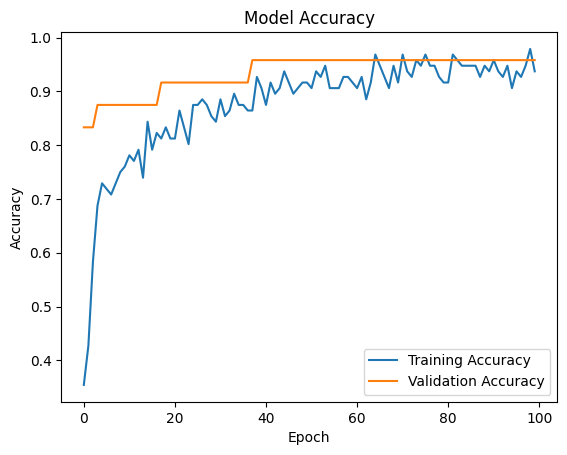

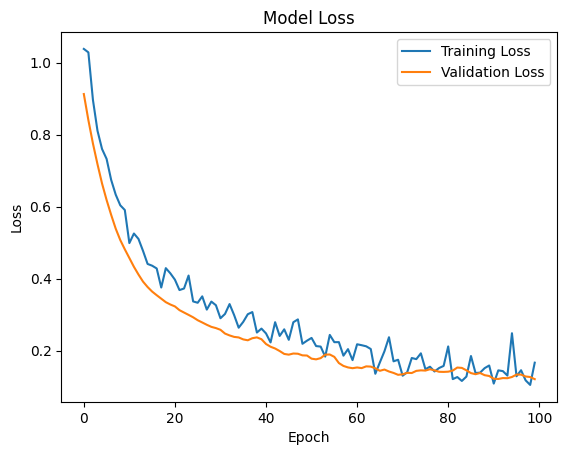

In [ ]:
# Region of convergence plot
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# Loss curve plot- training and validation loss curves to visualize convergence and potential overfitting
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()